## DRNSeg 语义分割

> 本lab用于展示Dilated Residual Network在ImageNet数据集上，不同层的激活图（activation maps）。通过观察这些激活图，我们可以更好地理解网络在不同层次上如何处理和提取图像特征。

- DRN官方链接: [GitHub](https://github.com/fyu/drn/tree/master)
<!-- > You can download the pretrained DRN models on Cityscapes here: http://go.yf.io/drn-cityscapes-models. -->

In [25]:
from torchvision import models
from models.drn.segment import DRNSeg
from tools.image_tools.image_tools import tensor2image, denormalize_tensor
from models.drn.segment import SegList
from models.drn import data_transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch

# ==============================
DATA_DIR = './datasets/seg/'
CITYSCAPE_PALETTE = np.asarray([
    [128, 64, 128],
    [244, 35, 232],
    [70, 70, 70],
    [102, 102, 156],
    [190, 153, 153],
    [153, 153, 153],
    [250, 170, 30],
    [220, 220, 0],
    [107, 142, 35],
    [152, 251, 152],
    [70, 130, 180],
    [220, 20, 60],
    [255, 0, 0],
    [0, 0, 142],
    [0, 0, 70],
    [0, 60, 100],
    [0, 80, 100],
    [0, 0, 230],
    [119, 11, 32],
    [0, 0, 0]], dtype=np.uint8)
# ==============================

### 查看模型结构和输出

In [2]:
model_pth = './models/drn-d-105_ms_cityscapes.pth'
# official github repo: https://github.com/fyu/drn/tree/master
# python3 segment.py test -d <data_folder> -c <category_number> --arch drn_d_105 \
    # --resume <model_path> --phase val --batch-size 1 --ms
single_model = DRNSeg("drn_d_105", 19, pretrained_model=None,
                          pretrained=False)
checkpoint = torch.load(model_pth)
single_model.load_state_dict(checkpoint)
model = single_model.eval()

In [3]:
from torchsummary import summary
summary(model, (3, 512, 512))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 512, 512]           2,352
       BatchNorm2d-2         [-1, 16, 512, 512]              32
              ReLU-3         [-1, 16, 512, 512]               0
            Conv2d-4         [-1, 16, 512, 512]           2,304
       BatchNorm2d-5         [-1, 16, 512, 512]              32
              ReLU-6         [-1, 16, 512, 512]               0
            Conv2d-7         [-1, 32, 256, 256]           4,608
       BatchNorm2d-8         [-1, 32, 256, 256]              64
              ReLU-9         [-1, 32, 256, 256]               0
           Conv2d-10         [-1, 64, 256, 256]           2,048
      BatchNorm2d-11         [-1, 64, 256, 256]             128
             ReLU-12         [-1, 64, 256, 256]               0
           Conv2d-13         [-1, 64, 128, 128]          36,864
      BatchNorm2d-14         [-1, 64, 1

In [4]:
input_tensor = torch.randn(1, 3, 512, 512)
output = model(input_tensor)
print("模型输出形状", output[1].shape)
print("上采样之后的形状", output[0].shape)

模型输出形状 torch.Size([1, 19, 64, 64])
上采样之后的形状 torch.Size([1, 19, 512, 512])


### 测试

In [37]:
from PIL import Image
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
seg_list = SegList(DATA_DIR, 'lab',transforms.Compose([
    # transforms.RandomCrop(crop_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD),
]))
lab_loader = torch.utils.data.DataLoader(seg_list, batch_size=1, shuffle=False, num_workers=0)

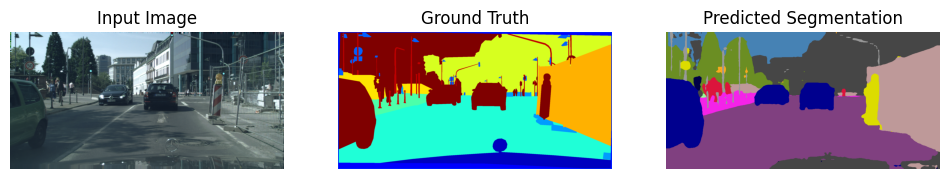

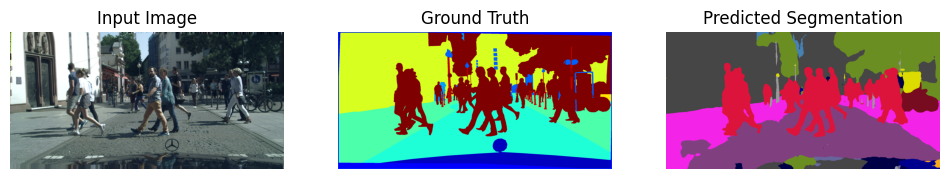

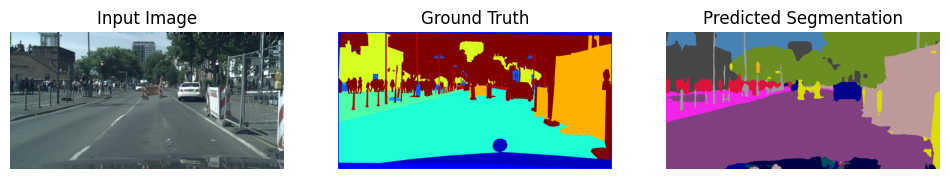

In [41]:
for i, (input_tensor, label_tensor) in enumerate(lab_loader):
    output = model(input_tensor)
    pred_tensor = output[0].argmax(dim=1)
    pred_images = tensor2image(pred_tensor, mode="mask", palette=CITYSCAPE_PALETTE)
    label_images = tensor2image(label_tensor, mode="mask")
    input_tensor = denormalize_tensor(input_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
    
    input_images = tensor2image(input_tensor)
    for i in range(len(input_images)):
        label_image = label_images[i]
        # label_image = label_images_ori[i]
        pred_image = pred_images[i]
        input_image = input_images[i]
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(input_image)
        axs[0].set_title('Input Image')
        axs[1].imshow(label_image, cmap='jet', vmin=0, vmax=18)
        axs[1].set_title('Ground Truth')
        axs[2].imshow(pred_image, cmap='jet', vmin=0, vmax=18)
        axs[2].set_title('Predicted Segmentation')
        for ax in axs:
            ax.axis('off')
        plt.show()
        if i == 2:
            break